In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df = pd.read_csv("netflix.csv")
df.columns = [c.strip() for c in df.columns]   # tidy up column names
df.head()

,title,rating,ratingLevel,ratingDescription,release year,user rating score,user rating size
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",80,2004,82.0,80
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",100,2006,NaN,82
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,98.0,80
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2008,98.0,80
4,How I Met Your Mother,TV-PG,Parental guidance suggested. May not be suitab...,70,2014,94.0,80


In [7]:
print("Shape:", df.shape)
print()
print("Titles per content rating:")
print(df["rating"].value_counts())
print()
print("Titles with a valid user rating score:",
      df["user rating score"].notna().sum())

Shape: (1000, 7)

Titles per content rating:
rating
TV-14       234
PG          170
TV-MA       148
G           138
TV-Y         68
TV-PG        59
TV-G         52
TV-Y7-FV     44
TV-Y7        38
R            19
PG-13        15
NR           14
UR            1
Name: count, dtype: int64

Titles with a valid user rating score: 605


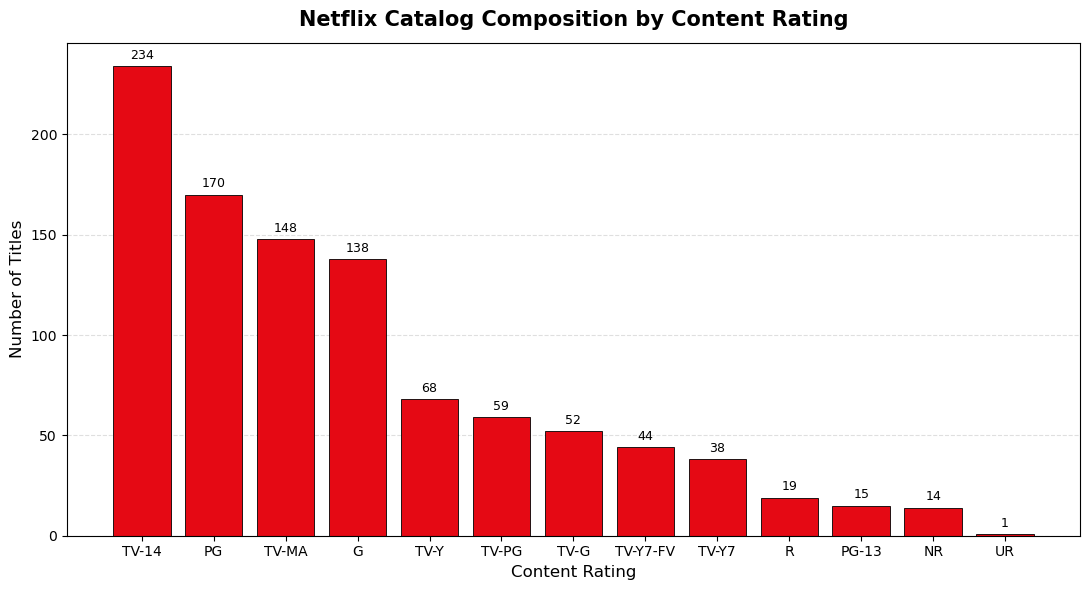

In [8]:
counts = df["rating"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(counts.index, counts.values,
              color="#E50914", edgecolor="black", linewidth=0.6)

ax.set_title("Netflix Catalog Composition by Content Rating",
             fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Content Rating", fontsize=12)
ax.set_ylabel("Number of Titles", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{int(height)}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig("1_bar_ratings.png", dpi=150)
plt.show()


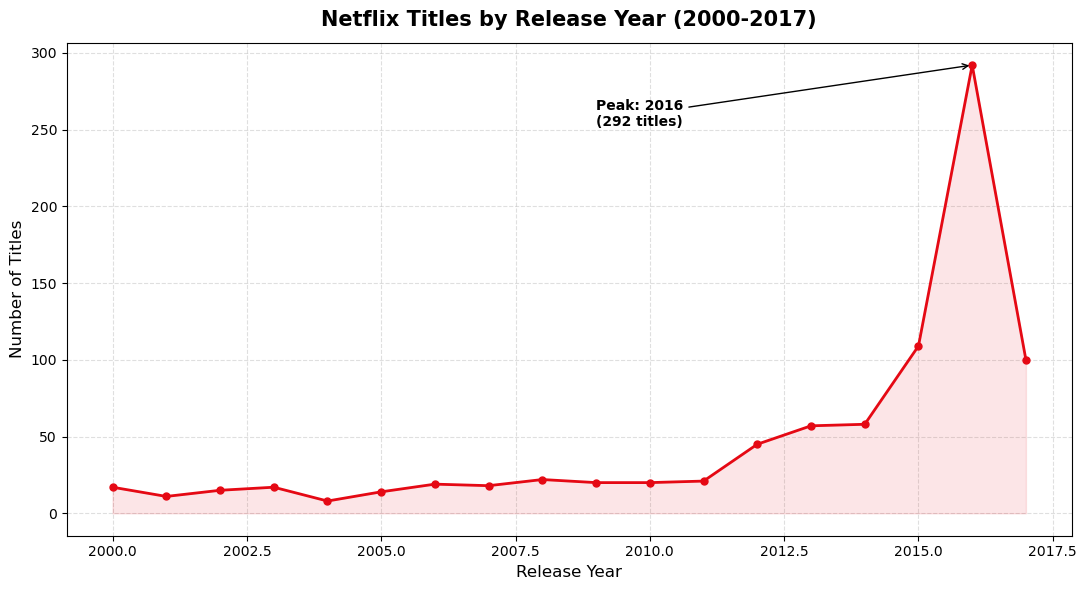

In [9]:
by_year = df.groupby("release year").size()
by_year = by_year[by_year.index >= 2000]   # focus on the modern era

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(by_year.index, by_year.values,
        color="#E50914", marker="o", markersize=5, linewidth=2)
ax.fill_between(by_year.index, by_year.values, color="#E50914", alpha=0.10)

ax.set_title("Netflix Titles by Release Year (2000-2017)",
             fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Release Year", fontsize=12)
ax.set_ylabel("Number of Titles", fontsize=12)
ax.grid(linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

peak_year = by_year.idxmax()
peak_val = by_year.max()
ax.annotate(f"Peak: {peak_year}\n({peak_val} titles)",
            xy=(peak_year, peak_val),
            xytext=(peak_year - 7, peak_val - 40),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, fontweight="bold")

fig.tight_layout()
fig.savefig("2_line_years.png", dpi=150)
plt.show()

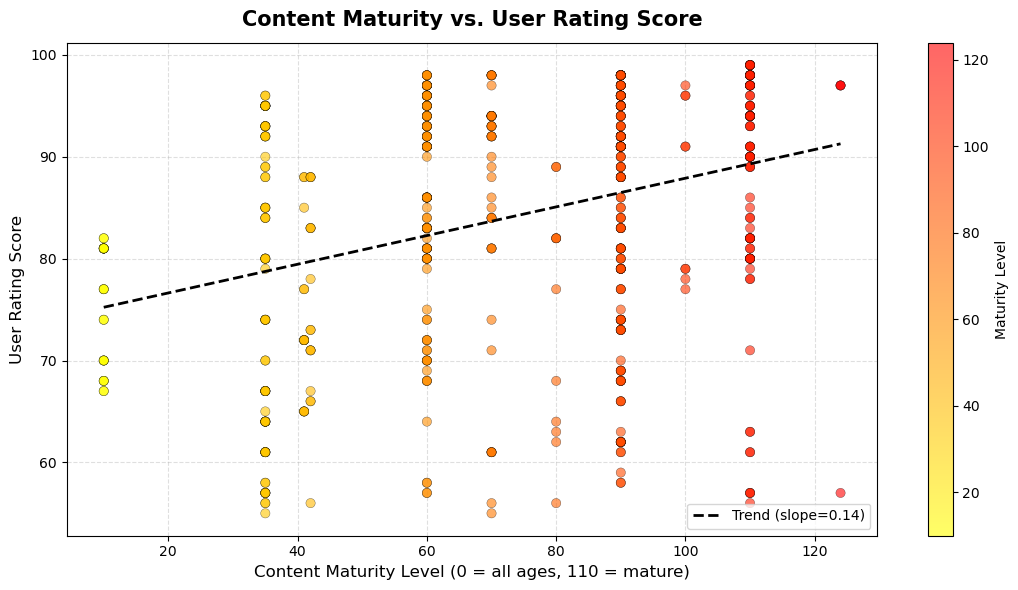

In [12]:
sub = df.dropna(subset=["user rating score"])

fig, ax = plt.subplots(figsize=(11, 6))
scatter = ax.scatter(sub["ratingDescription"], sub["user rating score"],
                     c=sub["ratingDescription"], cmap="autumn_r",
                     s=45, alpha=0.6, edgecolor="black", linewidth=0.3)

ax.set_title("Content Maturity vs. User Rating Score",
             fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Content Maturity Level (0 = all ages, 110 = mature)", fontsize=12)
ax.set_ylabel("User Rating Score", fontsize=12)
ax.grid(linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# trend line (least-squares fit)
x = sub["ratingDescription"].values
y = sub["user rating score"].values
m, b = np.polyfit(x, y, 1)
xs = np.array([x.min(), x.max()])
ax.plot(xs, m * xs + b, color="black", linestyle="--",
        linewidth=2, label=f"Trend (slope={m:.2f})")
ax.legend(loc="lower right", fontsize=10)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Maturity Level", fontsize=10)

fig.tight_layout()
fig.savefig("3_scatter_maturity_rating.png", dpi=150)
plt.show()